# Pertemuan 05 — Hands-on 05: CNN Efisien & Modern — MobileNet, ConvNeXt, dan Perbandingan Arsitektur
**Mata Kuliah:** Deep Learning (IF25-40401) — Program Studi Teknik Informatika, Institut Teknologi Sumatera (ITERA)
**Materi:** Depthwise Separable Convolution, Width & Resolution Multiplier, Inverted Residual & Linear Bottleneck, ConvNeXt Block, Perbandingan 10 Backbone, Inferensi Bobot Pretrained
**Alokasi Waktu:** ~45 Menit (Tatap Muka Kelas TM 3×50′)
**Slide Terkait:** Pertemuan 5, Bagian 03–05 (Slide 28–41)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/informatika-itera/deep-learning-IF25-40401/blob/main/materials/notebooks/05-mobilenet-convnext-perbandingan.ipynb)

---

### Capaian Pembelajaran (Sub-CPMK)
1. **Sub-CPMK 4:** Membandingkan efisiensi MobileNet (*depthwise separable*) dengan CNN standar melalui jumlah parameter, MAC, dan latensi terukur.
2. **Sub-CPMK 5:** Mengidentifikasi elemen modern ConvNeXt (depthwise $7\times7$, LayerNorm, MLP $4\times$, GELU) dan padanannya pada Transformer.
3. **Jembatan P6:** Membaca *trade-off* akurasi–komputasi dari 10 backbone `torchvision` dan menyiapkan backbone pretrained untuk *fine-tuning*.

---

### Konfigurasi Mode Eksekusi
- `MODE_CEPAT = True` mengurangi jumlah pengulangan pengukuran latensi.
- `UNDUH_PRETRAINED = True` mengunduh bobot MobileNetV3-Large (~22 MB) dan ResNet-50 (~98 MB) untuk Bagian 6. Setel ke `False` bila koneksi terbatas; bagian lain tetap berjalan **luring** karena memakai model tanpa bobot (`weights=None`).

In [1]:
# Saklar Kecepatan Eksekusi untuk Live-Coding di Kelas
MODE_CEPAT = True         # True: 5 pengulangan latensi | False: 20 pengulangan
UNDUH_PRETRAINED = True   # False: lewati Bagian 6 (tanpa unduhan bobot)

import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.cbook as cbook

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.flop_counter import FlopCounterMode
import torchvision
from torchvision import models
from torchvision.models.mobilenetv2 import InvertedResidual as TVInvertedResidual
from torchvision.models.convnext import CNBlock

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
N_ULANG = 5 if MODE_CEPAT else 20

TEAL, BLUE, ORANGE, INK, MUTE = '#0A7281', '#1151FF', '#DE8F05', '#111111', '#707072'


def hitung_param(model):
    return sum(p.numel() for p in model.parameters())


def hitung_mac(model, input_size=(1, 3, 224, 224)):
    """Total multiply-accumulate. FlopCounterMode menghitung FLOP = 2 x MAC."""
    model.eval()
    with FlopCounterMode(display=False) as fc, torch.no_grad():
        model(torch.randn(*input_size))
    return fc.get_total_flops() / 2


def ukur_latensi(model, input_size, n_ulang=N_ULANG):
    """Median waktu forward (ms) di CPU, setelah 2 kali pemanasan."""
    model.eval()
    x = torch.randn(*input_size)
    with torch.inference_mode():
        for _ in range(2):
            model(x)
        waktu = []
        for _ in range(n_ulang):
            t0 = time.perf_counter()
            model(x)
            waktu.append((time.perf_counter() - t0) * 1000)
    return float(np.median(waktu))


print("=" * 65)
print(f"PyTorch / Torchvision : {torch.__version__} / {torchvision.__version__}")
print(f"Perangkat Komputasi   : {device} (pengukuran latensi selalu di CPU)")
print(f"Thread CPU            : {torch.get_num_threads()}")
print(f"oneDNN (mkldnn) CPU   : {torch.backends.mkldnn.is_available()}  (memengaruhi kecepatan depthwise di CPU, lihat Bagian 5)")
print("=" * 65)

PyTorch / Torchvision : 2.14.0 / 0.29.0
Perangkat Komputasi   : mps (pengukuran latensi selalu di CPU)
Thread CPU            : 6
oneDNN (mkldnn) CPU   : False  (memengaruhi kecepatan depthwise di CPU, lihat Bagian 5)


## 1. Konvolusi Standar vs Depthwise Separable (Slide 28–29)

Konvolusi standar melakukan **dua pekerjaan sekaligus**: menyaring pola spasial *dan* mencampur kanal. MobileNet memisahkannya:
1. **Depthwise** $K\times K$: satu filter per kanal (tidak mencampur kanal), biaya $D_K^2 \cdot M \cdot D_F^2$.
2. **Pointwise** $1\times1$: mencampur kanal, biaya $M \cdot N \cdot D_F^2$.

$$\frac{\text{separable}}{\text{standar}} = \frac{D_K^2 M D_F^2 + M N D_F^2}{D_K^2 M N D_F^2} = \frac{1}{N} + \frac{1}{D_K^2}$$

Kode `dw_separable` di bawah disalin dari slide 30. Kita cek angka slide 29: $3\times3$, $M=N=256$, $D_F=56$.

In [2]:
def dw_separable(c_in, c_out, stride=1):
    return nn.Sequential(
        # depthwise: groups=c_in -> 1 filter per kanal
        nn.Conv2d(c_in, c_in, 3, stride, 1,
                  groups=c_in, bias=False),
        nn.BatchNorm2d(c_in), nn.ReLU(inplace=True),
        # pointwise: konvolusi 1x1 mencampur kanal
        nn.Conv2d(c_in, c_out, 1, bias=False),
        nn.BatchNorm2d(c_out), nn.ReLU(inplace=True))


M = N = 256
ukuran = (1, M, 56, 56)
standar = nn.Conv2d(M, N, 3, padding=1, bias=False)
depthwise = nn.Conv2d(M, M, 3, padding=1, groups=M, bias=False)
pointwise = nn.Conv2d(M, N, 1, bias=False)

print(f"{'Operasi':<12}{'MAC':>16}{'Bobot':>12}")
print("-" * 40)
for nama, m in [("Standar", standar), ("Depthwise", depthwise), ("Pointwise", pointwise)]:
    print(f"{nama:<12}{hitung_mac(m, ukuran):>16,.0f}{hitung_param(m):>12,}")
sep_mac = hitung_mac(depthwise, ukuran) + hitung_mac(pointwise, ukuran)
sep_w = hitung_param(depthwise) + hitung_param(pointwise)
print("-" * 40)
print(f"{'Separable':<12}{sep_mac:>16,.0f}{sep_w:>12,}")

print(f"\nRasio terukur  : {sep_mac / hitung_mac(standar, ukuran):.4f}")
print(f"Rasio rumus    : 1/{N} + 1/9 = {1/N + 1/9:.4f}  -> hemat {1/(1/N + 1/9):.1f}x")
print(f"Porsi pointwise: {hitung_mac(pointwise, ukuran)/sep_mac:.1%} dari biaya separable")

blok = dw_separable(256, 256)
print(f"\nBobot conv dw_separable(256,256) = {sum(m.weight.numel() for m in blok if isinstance(m, nn.Conv2d)):,} (cocok dengan slide 30)")

Operasi                  MAC       Bobot
----------------------------------------
Standar        1,849,688,064     589,824
Depthwise          7,225,344       2,304
Pointwise        205,520,896      65,536
----------------------------------------
Separable        212,746,240      67,840

Rasio terukur  : 0.1150
Rasio rumus    : 1/256 + 1/9 = 0.1150  -> hemat 8.7x
Porsi pointwise: 96.6% dari biaya separable

Bobot conv dw_separable(256,256) = 67,840 (cocok dengan slide 30)


### 1b. Apa yang Sebenarnya Dilakukan Argumen `groups`?

Dengan `groups=C`, kanal input dibagi menjadi $C$ kelompok berisi 1 kanal, dan setiap kelompok punya filternya sendiri. Bentuk tensor bobot memperlihatkannya: dimensi kedua (kanal input per filter) menyusut menjadi 1.

In [3]:
print(f"Bobot standar  : {tuple(standar.weight.shape)}   (C_out, C_in, K, K)")
print(f"Bobot depthwise: {tuple(depthwise.weight.shape)}     (C_out, C_in/groups = 1, K, K)")
print(f"Bobot pointwise: {tuple(pointwise.weight.shape)}   (C_out, C_in, 1, 1)")

# Bukti: kanal ke-7 output depthwise HANYA bergantung pada kanal ke-7 input
x = torch.randn(1, M, 56, 56)
with torch.no_grad():
    y_dw = depthwise(x)
    y_manual = F.conv2d(x[:, 7:8], depthwise.weight[7:8], padding=1)
print(f"\nKanal 7 depthwise == konvolusi kanal 7 saja? {torch.allclose(y_dw[:, 7:8], y_manual, atol=1e-5)}")

Bobot standar  : (256, 256, 3, 3)   (C_out, C_in, K, K)
Bobot depthwise: (256, 1, 3, 3)     (C_out, C_in/groups = 1, K, K)
Bobot pointwise: (256, 256, 1, 1)   (C_out, C_in, 1, 1)

Kanal 7 depthwise == konvolusi kanal 7 saja? True


### 1c. Pengaruh Ukuran Kernel dan Jumlah Kanal pada Rasio Biaya

Rasio $\frac{1}{N} + \frac{1}{D_K^2}$ didominasi suku $\frac{1}{D_K^2}$ begitu $N$ cukup besar. Perhatikan bagaimana kurva untuk kernel yang lebih besar turun lebih jauh.

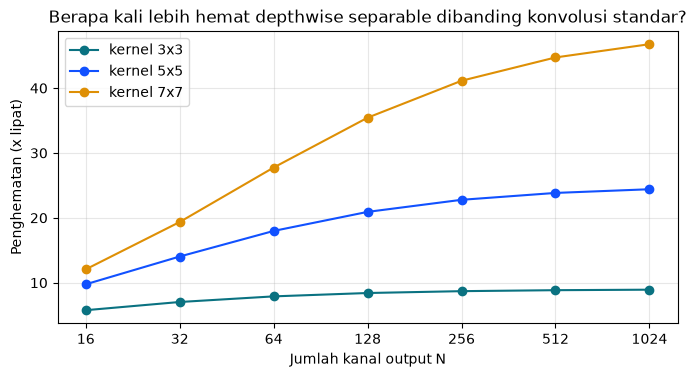

In [4]:
N_list = np.array([16, 32, 64, 128, 256, 512, 1024])
plt.figure(figsize=(8, 3.8))
for k, warna in [(3, TEAL), (5, BLUE), (7, ORANGE)]:
    rasio = 1 / N_list + 1 / k**2
    plt.plot(N_list, 1 / rasio, 'o-', color=warna, label=f'kernel {k}x{k}')
plt.xscale('log', base=2)
plt.xticks(N_list, N_list)
plt.xlabel('Jumlah kanal output N')
plt.ylabel('Penghematan (x lipat)')
plt.title('Berapa kali lebih hemat depthwise separable dibanding konvolusi standar?')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 1d. MAC Bukan Latensi

Penghematan MAC tidak otomatis menjadi percepatan yang sama besar. Konvolusi depthwise punya **intensitas aritmetika rendah**: sedikit operasi per byte data yang dibaca dari memori, sehingga sering dibatasi oleh *memory bandwidth*, bukan oleh kecepatan hitung. Mari kita ukur di CPU.

In [5]:
ukuran_batch = (8, M, 56, 56)
t_std = ukur_latensi(standar, ukuran_batch)
t_dw = ukur_latensi(depthwise, ukuran_batch)
t_pw = ukur_latensi(pointwise, ukuran_batch)
t_sep = ukur_latensi(nn.Sequential(depthwise, pointwise), ukuran_batch)

print(f"Standar 3x3        : {t_std:7.2f} ms")
print(f"Depthwise 3x3      : {t_dw:7.2f} ms  (hanya {hitung_mac(depthwise, ukuran)/sep_mac:.1%} MAC)")
print(f"Pointwise 1x1      : {t_pw:7.2f} ms")
print(f"Separable (dw + pw): {t_sep:7.2f} ms")
print(f"\nPenghematan MAC     : {hitung_mac(standar, ukuran)/sep_mac:.1f}x")
print(f"Percepatan terukur  : {t_std/t_sep:.1f}x   (bergantung perangkat keras & library)")

Standar 3x3        :   20.77 ms
Depthwise 3x3      :    3.55 ms  (hanya 3.4% MAC)
Pointwise 1x1      :    2.38 ms
Separable (dw + pw):    5.60 ms

Penghematan MAC     : 8.7x
Percepatan terukur  : 3.7x   (bergantung perangkat keras & library)


## 2. MobileNetV1 Utuh: *Width Multiplier* $\alpha$ dan *Resolution Multiplier* $\rho$ (Slide 30)

MobileNetV1 = satu conv standar $3\times3$ (stride 2) + **13 blok depthwise separable** + *global average pooling* + FC. Dua "kenop" efisiensinya:
- $\alpha$ mengalikan **jumlah kanal** setiap layer, sehingga biaya turun $\approx \alpha^2$.
- $\rho$ mengecilkan **resolusi input**, sehingga biaya turun $\approx \rho^2$.

Makalah Howard et al. (2017) melaporkan MobileNet-224 ($\alpha = 1$): **4,2 juta parameter, 569 juta mult-adds**. Mari kita rakit dan verifikasi.

In [6]:
# (kanal output, stride) untuk 13 blok depthwise separable
CFG_V1 = [(64, 1), (128, 2), (128, 1), (256, 2), (256, 1), (512, 2),
          (512, 1), (512, 1), (512, 1), (512, 1), (512, 1), (1024, 2), (1024, 1)]


class MobileNetV1(nn.Module):
    def __init__(self, alpha=1.0, n_kelas=1000):
        super().__init__()
        c = int(32 * alpha)
        layers = [nn.Conv2d(3, c, 3, 2, 1, bias=False), nn.BatchNorm2d(c), nn.ReLU(inplace=True)]
        for c_out, s in CFG_V1:
            layers.append(dw_separable(c, int(c_out * alpha), s))
            c = int(c_out * alpha)
        self.features = nn.Sequential(*layers)
        self.fc = nn.Linear(c, n_kelas)

    def forward(self, x):
        return self.fc(F.adaptive_avg_pool2d(self.features(x), 1).flatten(1))


print(f"{'alpha':<7}{'res':<6}{'Parameter':>12}{'Juta MAC':>11}{'MAC relatif':>13}{'teori a^2 r^2':>15}")
basis = hitung_mac(MobileNetV1(1.0))
hasil_v1 = []
for alpha, res in [(1.0, 224), (0.75, 224), (0.5, 224), (0.25, 224), (1.0, 192), (1.0, 160), (1.0, 128)]:
    m = MobileNetV1(alpha)
    mac = hitung_mac(m, (1, 3, res, res))
    hasil_v1.append((alpha, res, mac))
    print(f"{alpha:<7}{res:<6}{hitung_param(m)/1e6:>10.2f} jt{mac/1e6:>11.0f}{mac/basis:>13.3f}{alpha**2 * (res/224)**2:>15.3f}")

alpha  res      Parameter   Juta MAC  MAC relatif  teori a^2 r^2


1.0    224         4.23 jt        569        1.000          1.000


0.75   224         2.59 jt        325        0.572          0.562
0.5    224         1.33 jt        149        0.263          0.250
0.25   224         0.47 jt         41        0.072          0.062


1.0    192         4.23 jt        418        0.735          0.735


1.0    160         4.23 jt        291        0.511          0.510
1.0    128         4.23 jt        186        0.328          0.327


Angka $\alpha = 1$, 224 piksel cocok dengan makalah (4,2 juta parameter, ~569 juta MAC). Rasio terukur mengikuti $\alpha^2\rho^2$ dengan cukup dekat. Selisihnya berasal dari layer yang tidak berskala kuadratik, misalnya conv pertama (input selalu 3 kanal) dan depthwise yang biayanya hanya linear terhadap $\alpha$.

---

## 3. MobileNetV2: *Inverted Residual* dan *Linear Bottleneck* (Slide 31)

Blok ResNet bottleneck berbentuk **lebar → sempit → lebar**. MobileNetV2 membaliknya menjadi **sempit → lebar → sempit**:
1. $1\times1$ **ekspansi** $c \to tc$ ($t = 6$), ReLU6.
2. $3\times3$ **depthwise** pada tensor lebar, ReLU6.
3. $1\times1$ **proyeksi** $tc \to c$, **tanpa aktivasi** (*linear bottleneck*).
4. *Skip connection* antar tensor sempit, hanya bila stride 1 dan $c_{in} = c_{out}$.

In [7]:
class InvertedResidual(nn.Module):
    def __init__(self, c_in, c_out, stride, t=6):
        super().__init__()
        c_mid = c_in * t
        self.pakai_skip = stride == 1 and c_in == c_out
        self.blok = nn.Sequential(
            nn.Conv2d(c_in, c_mid, 1, bias=False), nn.BatchNorm2d(c_mid), nn.ReLU6(inplace=True),       # ekspansi
            nn.Conv2d(c_mid, c_mid, 3, stride, 1, groups=c_mid, bias=False),                             # depthwise
            nn.BatchNorm2d(c_mid), nn.ReLU6(inplace=True),
            nn.Conv2d(c_mid, c_out, 1, bias=False), nn.BatchNorm2d(c_out))                               # proyeksi linear

    def forward(self, x):
        out = self.blok(x)
        return x + out if self.pakai_skip else out


blok_kita = InvertedResidual(24, 24, stride=1, t=6)
blok_tv = TVInvertedResidual(24, 24, stride=1, expand_ratio=6)
print(f"Parameter blok kita       : {hitung_param(blok_kita):,}")
print(f"Parameter blok torchvision: {hitung_param(blok_tv):,}")

x = torch.randn(1, 24, 56, 56)
print("\nBentuk tensor di dalam blok (sempit -> lebar -> sempit):")
h = x
for i, layer in enumerate(blok_kita.blok):
    h = layer(h)
    if isinstance(layer, nn.Conv2d):
        jenis = 'depthwise' if layer.groups > 1 else ('ekspansi' if layer.out_channels > layer.in_channels else 'proyeksi')
        print(f"  Conv {jenis:<10}: {tuple(h.shape[1:])}")
print(f"Output + skip  : {tuple(blok_kita(x).shape[1:])} | skip dipakai: {blok_kita.pakai_skip}")

Parameter blok kita       : 8,832
Parameter blok torchvision: 8,832

Bentuk tensor di dalam blok (sempit -> lebar -> sempit):
  Conv ekspansi  : (144, 56, 56)
  Conv depthwise : (144, 56, 56)
  Conv proyeksi  : (24, 56, 56)
Output + skip  : (24, 56, 56) | skip dipakai: True


### 3b. Mengapa Proyeksi Dibiarkan Linear? (Eksperimen Sandler et al., 2018, Gambar 1)

Hipotesis MobileNetV2: ReLU pada tensor berdimensi **rendah** membuang informasi. Eksperimennya sederhana:
1. Buat data berbentuk spiral 2D.
2. "Tanam" ke ruang berdimensi $n$ dengan matriks acak $T$, lalu terapkan ReLU: $y = \text{ReLU}(Tx)$.
3. Coba kembalikan ke 2D dengan **dekoder linear terbaik** $W$ (dicari dengan *least squares*): $\hat{x} = W y$. Jika bahkan dekoder terbaik pun gagal, berarti informasinya memang sudah hilang.

Jika $n$ kecil, banyak koordinat terpotong menjadi nol oleh ReLU dan spiral **rusak**. Jika $n$ besar, informasinya tetap bertahan.

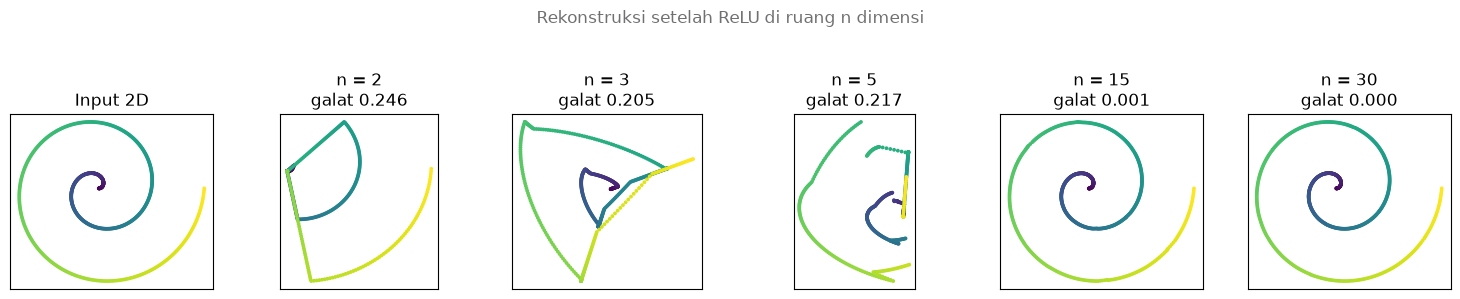

In [8]:
rng = np.random.default_rng(0)
sudut = np.linspace(0, 4 * np.pi, 600)
spiral = np.stack([sudut * np.cos(sudut), sudut * np.sin(sudut)], axis=1) / (4 * np.pi)

fig, axs = plt.subplots(1, 6, figsize=(15, 2.8))
axs[0].scatter(spiral[:, 0], spiral[:, 1], c=sudut, s=3, cmap='viridis')
axs[0].set_title('Input 2D')
for ax, n in zip(axs[1:], [2, 3, 5, 15, 30]):
    T = rng.normal(size=(n, 2))
    y = np.maximum(spiral @ T.T, 0)            # ReLU(Tx) di ruang n dimensi
    y1 = np.hstack([y, np.ones((len(y), 1))])    # tambah kolom bias
    W, *_ = np.linalg.lstsq(y1, spiral, rcond=None)
    rekon = y1 @ W                               # dekoder linear terbaik kembali ke 2D
    galat = np.mean(np.linalg.norm(rekon - spiral, axis=1))
    ax.scatter(rekon[:, 0], rekon[:, 1], c=sudut, s=3, cmap='viridis')
    ax.set_title(f'n = {n}\ngalat {galat:.3f}')
for ax in axs:
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal')
plt.suptitle('Rekonstruksi setelah ReLU di ruang n dimensi', color=MUTE, y=1.05)
plt.tight_layout()
plt.show()

Itulah alasan MobileNetV2 **mengekspansi dulu** sebelum ReLU (ReLU bekerja di ruang lebar yang aman), lalu **memproyeksikan secara linear** ke ruang sempit tanpa ReLU.

---

## 4. ConvNeXt Block: Elemen yang Diadopsi dari Transformer (Slide 36–37)

Kode `ConvNeXtBlock` di bawah disalin dari slide 37 (versi ringkas tanpa *layer scale* dan *stochastic depth*):
- **Depthwise $7\times7$**: pencampuran spasial per kanal, analog *self-attention* per jendela.
- **LayerNorm** menggantikan BatchNorm.
- **MLP $4\times$** (dua `nn.Linear` dengan GELU): analog *feed-forward network* Transformer.
- `nn.Linear` bekerja pada dimensi terakhir, sehingga tensor di-*permute* ke format *channels-last* `(B, H, W, C)`.

In [9]:
class ConvNeXtBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, 7, padding=3, groups=dim)
        self.norm = nn.LayerNorm(dim)      # channels-last
        self.pw1 = nn.Linear(dim, 4 * dim) # 1x1, ekspansi 4x
        self.act = nn.GELU()
        self.pw2 = nn.Linear(4 * dim, dim) # 1x1, proyeksi

    def forward(self, x):                  # (B, C, H, W)
        y = self.dwconv(x).permute(0, 2, 3, 1)   # (B, H, W, C)
        y = self.pw2(self.act(self.pw1(self.norm(y))))
        return x + y.permute(0, 3, 1, 2)         # residual


blok = ConvNeXtBlock(96)
blok_resmi = CNBlock(96, layer_scale=1e-6, stochastic_depth_prob=0.0)
print(f"Parameter ConvNeXtBlock kita   : {hitung_param(blok):,}")
print(f"Parameter CNBlock torchvision  : {hitung_param(blok_resmi):,}  (+96 = vektor layer scale gamma)")

x = torch.randn(2, 96, 56, 56)
print(f"\nInput {tuple(x.shape)} -> output {tuple(blok(x).shape)}  (shape dipertahankan, syarat residual)")

print("\nRincian parameter:")
for nama, p in blok.named_parameters():
    print(f"  {nama:<15}{str(tuple(p.shape)):<16}{p.numel():>8,}")

Parameter ConvNeXtBlock kita   : 79,200
Parameter CNBlock torchvision  : 79,296  (+96 = vektor layer scale gamma)

Input (2, 96, 56, 56) -> output (2, 96, 56, 56)  (shape dipertahankan, syarat residual)

Rincian parameter:
  dwconv.weight  (96, 1, 7, 7)      4,704
  dwconv.bias    (96,)                 96
  norm.weight    (96,)                 96
  norm.bias      (96,)                 96
  pw1.weight     (384, 96)         36,864
  pw1.bias       (384,)               384
  pw2.weight     (96, 384)         36,864
  pw2.bias       (96,)                 96


### 4b. `nn.Linear` pada Channels-Last = Konvolusi $1\times1$

Slide 37 menyatakan `nn.Linear` pada tensor *channels-last* setara dengan konvolusi $1\times1$. Mari kita buktikan dengan menyalin bobot yang sama ke keduanya.

In [10]:
linear = nn.Linear(96, 384)
conv1x1 = nn.Conv2d(96, 384, 1)
with torch.no_grad():
    conv1x1.weight.copy_(linear.weight.view(384, 96, 1, 1))
    conv1x1.bias.copy_(linear.bias)
    x = torch.randn(2, 96, 14, 14)
    via_linear = linear(x.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)
    via_conv = conv1x1(x)
print(f"Output identik? {torch.allclose(via_linear, via_conv, atol=1e-5)}  | selisih maks {(via_linear - via_conv).abs().max():.2e}")

Output identik? True  | selisih maks 7.15e-07


## 5. Perbandingan 10 Arsitektur pada ImageNet-1K (Slide 39–40)

Kita bangun kesepuluh model **tanpa mengunduh bobot** (`weights=None`), lalu:
- menghitung parameter dan GMAC sendiri,
- mengambil akurasi top-1 dari **metadata bobot resmi** `torchvision` (tersedia luring, tanpa unduhan),
- mengukur **latensi CPU** untuk satu citra $224\times224$.

> Latensi sangat bergantung pada perangkat keras, jumlah thread, dan versi library. Bandingkan urutan relatifnya, bukan angka absolutnya.

In [11]:
DAFTAR = [('AlexNet', 'alexnet', 2012), ('VGG-16', 'vgg16', 2014), ('GoogLeNet', 'googlenet', 2014),
          ('ResNet-18', 'resnet18', 2015), ('ResNet-50', 'resnet50', 2015), ('DenseNet-121', 'densenet121', 2017),
          ('MobileNetV2', 'mobilenet_v2', 2018), ('MobileNetV3-L', 'mobilenet_v3_large', 2019),
          ('EfficientNet-B0', 'efficientnet_b0', 2019), ('ConvNeXt-T', 'convnext_tiny', 2022)]

tabel = []
print(f"{'Model':<16}{'Tahun':>6}{'Param (jt)':>12}{'GMAC':>8}{'Top-1':>8}{'CPU (ms)':>10}")
print("-" * 60)
for nama, kunci, tahun in DAFTAR:
    kwargs = {'aux_logits': False, 'init_weights': False} if kunci == 'googlenet' else {}
    m = models.get_model(kunci, weights=None, **kwargs)
    top1 = models.get_model_weights(kunci).IMAGENET1K_V1.meta['_metrics']['ImageNet-1K']['acc@1']
    baris = (nama, tahun, hitung_param(m) / 1e6, hitung_mac(m) / 1e9, top1, ukur_latensi(m, (1, 3, 224, 224)))
    tabel.append(baris)
    print(f"{baris[0]:<16}{baris[1]:>6}{baris[2]:>12.1f}{baris[3]:>8.2f}{baris[4]:>7.1f}%{baris[5]:>10.1f}")

Model            Tahun  Param (jt)    GMAC   Top-1  CPU (ms)
------------------------------------------------------------


AlexNet           2012        61.1    0.71   56.5%      13.2


VGG-16            2014       138.4   15.47   71.6%      56.4


GoogLeNet         2014         6.6    1.50   69.8%      22.4


ResNet-18         2015        11.7    1.81   69.8%      13.2


...

DenseNet-121      2017         8.0    2.83   74.4%      44.3


MobileNetV2       2018         3.5    0.30   71.9%      75.8


MobileNetV3-L     2019         5.5    0.22   74.0%     201.9


EfficientNet-B0   2019         5.3    0.39   77.7%     413.0


ConvNeXt-T        2022        28.6    4.46   82.5%     682.3


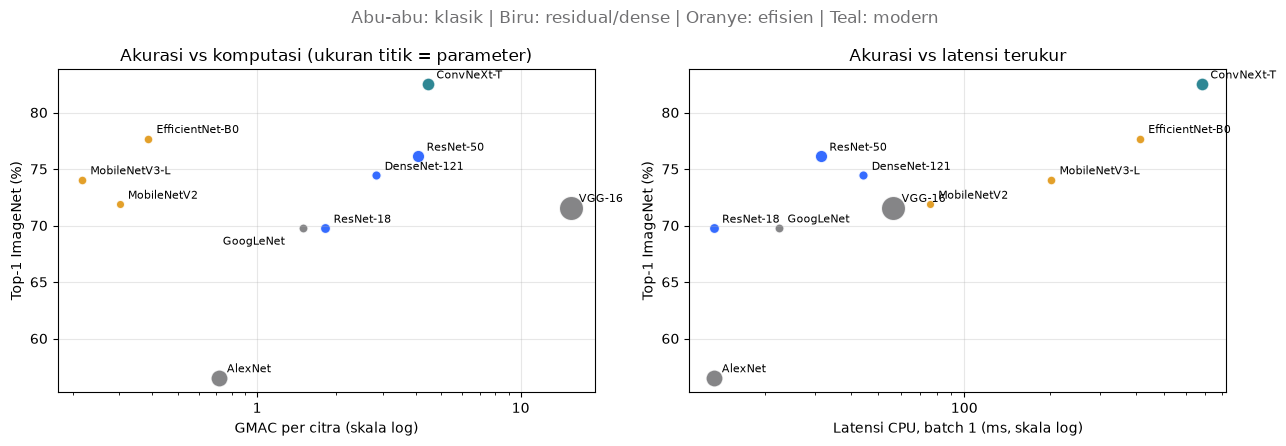

In [12]:
kelompok = {'AlexNet': MUTE, 'VGG-16': MUTE, 'GoogLeNet': MUTE,
            'ResNet-18': BLUE, 'ResNet-50': BLUE, 'DenseNet-121': BLUE,
            'MobileNetV2': ORANGE, 'MobileNetV3-L': ORANGE, 'EfficientNet-B0': ORANGE, 'ConvNeXt-T': TEAL}

fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, idx, xlabel in [(axs[0], 3, 'GMAC per citra (skala log)'), (axs[1], 5, 'Latensi CPU, batch 1 (ms, skala log)')]:
    for baris in tabel:
        ukuran_titik = 30 + baris[2] * 2          # ukuran titik ~ jumlah parameter
        ax.scatter(baris[idx], baris[4], s=ukuran_titik, color=kelompok[baris[0]], alpha=0.85, edgecolor='white')
        geser = (-58, -12) if baris[0] == 'GoogLeNet' and idx == 3 else (6, 4)
        ax.annotate(baris[0], (baris[idx], baris[4]), textcoords='offset points', xytext=geser, fontsize=8)
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}'))
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Top-1 ImageNet (%)')
    ax.grid(alpha=0.3)
axs[0].set_title('Akurasi vs komputasi (ukuran titik = parameter)')
axs[1].set_title('Akurasi vs latensi terukur')
plt.suptitle('Abu-abu: klasik | Biru: residual/dense | Oranye: efisien | Teal: modern', color=MUTE)
plt.tight_layout()
plt.show()

**Cara membaca grafik:**
1. Model **kiri atas** adalah yang paling efisien: akurasi tinggi dengan komputasi rendah (EfficientNet-B0, MobileNetV3).
2. VGG-16 berada di kanan bawah: komputasi terbesar, akurasi setara MobileNetV2.
3. Urutan pada grafik latensi **bisa sangat berbeda** dengan grafik GMAC. Model yang banyak memakai konvolusi depthwise (MobileNet, EfficientNet, ConvNeXt) sering jauh lebih lambat daripada yang dijanjikan GMAC-nya, sesuai temuan Bagian 1d.

> **Catatan perangkat keras:** efek ini paling ekstrem bila PyTorch tidak memiliki **oneDNN** (lihat output sel setup; contohnya build PyTorch untuk macOS ARM). Tanpa oneDNN, depthwise dijalankan dengan implementasi generik yang lambat, sehingga ConvNeXt-T bisa terlihat lebih lambat daripada VGG-16 walau GMAC-nya 3,5× lebih kecil. Di Colab (CPU x86 dengan oneDNN) atau di GPU, urutannya akan berbeda. Pelajarannya: **selalu ukur latensi pada perangkat target**, jangan hanya mengandalkan GMAC.

---

## 6. Inferensi dengan Bobot Pretrained & Persiapan Fine-tuning (Slide 41, Jembatan P6)

Setiap bobot `torchvision` membawa **pipeline preprocessing** (`weights.transforms()`) dan **daftar nama kelas** (`weights.meta['categories']`). Kita klasifikasikan citra contoh bawaan Matplotlib (`grace_hopper.jpg`) dengan dua backbone.

MobileNetV3-L: input (1, 3, 224, 224) | prediksi teratas: military uniform (34.8%)


ResNet-50: input (1, 3, 224, 224) | prediksi teratas: bow tie (73.0%)


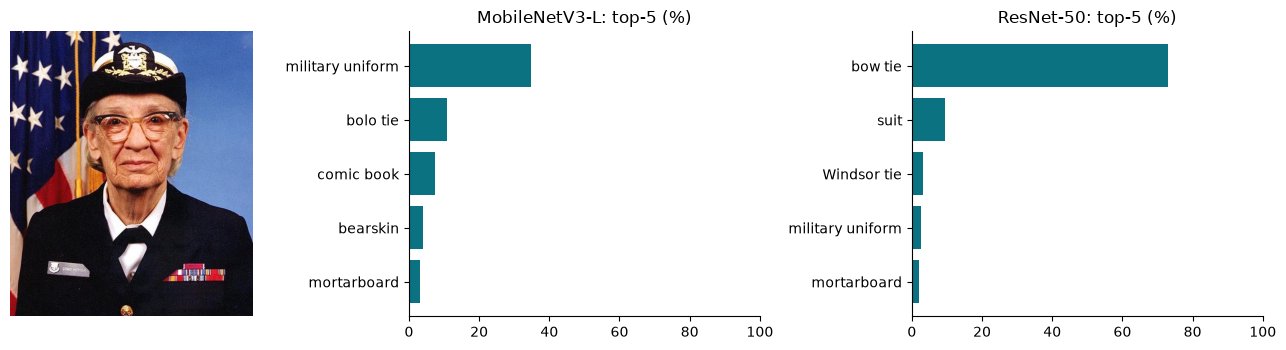

In [13]:
citra = Image.open(cbook.get_sample_data('grace_hopper.jpg')).convert('RGB')
hasil_pretrained = {}

if UNDUH_PRETRAINED:
    for nama, kunci in [('MobileNetV3-L', 'mobilenet_v3_large'), ('ResNet-50', 'resnet50')]:
        try:
            bobot = models.get_model_weights(kunci).IMAGENET1K_V1
            model = models.get_model(kunci, weights=bobot, progress=False).eval()
            x = bobot.transforms()(citra).unsqueeze(0)
            with torch.no_grad():
                prob = model(x).softmax(dim=1)[0]
            top5 = prob.topk(5)
            hasil_pretrained[nama] = [(bobot.meta['categories'][i], p.item()) for p, i in zip(top5.values, top5.indices)]
            print(f"{nama}: input {tuple(x.shape)} | prediksi teratas: {hasil_pretrained[nama][0][0]} ({hasil_pretrained[nama][0][1]:.1%})")
        except Exception as e:
            print(f"Gagal memuat {nama} (periksa koneksi internet): {e}")
else:
    print("UNDUH_PRETRAINED = False, bagian ini dilewati.")

if hasil_pretrained:
    fig, axs = plt.subplots(1, 1 + len(hasil_pretrained), figsize=(13, 3.6), gridspec_kw={'width_ratios': [1] + [1.4] * len(hasil_pretrained)})
    axs[0].imshow(citra)
    axs[0].axis('off')
    for ax, (nama, top5) in zip(axs[1:], hasil_pretrained.items()):
        label = [k for k, _ in top5][::-1]
        nilai = [p * 100 for _, p in top5][::-1]
        ax.barh(label, nilai, color=TEAL)
        ax.set_xlim(0, 100)
        ax.set_title(f'{nama}: top-5 (%)')
        ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

### 6b. Mengganti *Head* untuk Dataset Baru

Pada Studio Proyek 2 (P6) Anda akan memakai backbone pretrained untuk dataset dengan jumlah kelas berbeda. Letak *head* berbeda-beda per arsitektur (slide 41). Kode di bawah memakai `weights=None` agar berjalan tanpa unduhan; di P6 cukup ganti dengan bobot pretrained.

In [14]:
N_KELAS_BARU = 5

def siapkan_backbone(kunci, n_kelas, bekukan=True):
    m = models.get_model(kunci, weights=None)
    if bekukan:                                   # linear probing: hanya head yang dilatih
        for p in m.parameters():
            p.requires_grad = False
    if kunci.startswith('resnet'):
        m.fc = nn.Linear(m.fc.in_features, n_kelas)
    elif kunci.startswith('mobilenet_v3'):
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, n_kelas)
    elif kunci.startswith('convnext'):
        m.classifier[2] = nn.Linear(m.classifier[2].in_features, n_kelas)
    return m


print(f"{'Backbone':<20}{'Total param':>14}{'Dilatih (head)':>16}{'Output':>12}")
for kunci in ['resnet50', 'mobilenet_v3_large', 'convnext_tiny']:
    m = siapkan_backbone(kunci, N_KELAS_BARU)
    dilatih = sum(p.numel() for p in m.parameters() if p.requires_grad)
    out = m.eval()(torch.randn(1, 3, 224, 224))
    print(f"{kunci:<20}{hitung_param(m):>14,}{dilatih:>16,}{str(tuple(out.shape)):>12}")

Backbone               Total param  Dilatih (head)      Output


resnet50                23,518,277          10,245      (1, 5)


mobilenet_v3_large       4,208,437           6,405      (1, 5)


convnext_tiny           27,823,973           3,845      (1, 5)


---

## 7. Ringkasan & Tugas Terstruktur (TT 3×60′)

### Ringkasan Eksperimen:
1. **Depthwise separable** memangkas bobot dan MAC ~8,7× (rasio $\frac{1}{N} + \frac{1}{D_K^2}$), dengan ~97% biaya tersisa ada di pointwise $1\times1$.
2. **MAC ≠ latensi:** depthwise dibatasi *memory bandwidth*, sehingga percepatan nyata lebih kecil daripada penghematan MAC.
3. **MobileNetV1** hasil rakitan sendiri cocok dengan makalah (4,2 juta parameter, ~569 juta MAC); biaya berskala $\approx\alpha^2\rho^2$.
4. **Linear bottleneck:** ReLU di ruang berdimensi rendah merusak informasi (eksperimen spiral), karena itu proyeksi MobileNetV2 dibiarkan linear.
5. **ConvNeXt block** = depthwise $7\times7$ + LayerNorm + MLP $4\times$ + GELU + residual; `nn.Linear` channels-last identik dengan konvolusi $1\times1$.

---

### Soal Tugas Terstruktur:
1. **Tugas 1 — Verifikasi Latihan Slide:** ubah Bagian 1 menjadi kernel $5\times5$ (tetap $M = N = 256$) dan cocokkan rasio biaya terukur dengan jawaban Latihan Mandiri no. 3 (slide 54).
2. **Tugas 2 — Latensi di GPU:** jalankan ulang Bagian 1d dan 5 di Google Colab (GPU T4) dengan memindahkan model dan input ke `cuda` (gunakan `torch.cuda.synchronize()` sebelum membaca waktu). Apakah urutan model berubah?
3. **Tugas 3 — Rekomendasi Backbone:** berdasarkan tabel Bagian 5, pilih dua backbone untuk aplikasi deteksi penyakit daun di ponsel petani (Latihan Mandiri no. 5). Justifikasi dengan angka parameter, GMAC, latensi, dan top-1.
4. **Tugas 4 — Ablasi ReLU6:** ganti proyeksi linear pada `InvertedResidual` dengan `nn.Sequential(conv, bn, nn.ReLU6())`. Jelaskan dengan eksperimen spiral Bagian 3b mengapa perubahan ini merugikan.